In [3]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# Configurações da clínica fictícia
n = 500
servicos = [
    "Limpeza de Pele", "Botox", "Preenchimento Labial",
    "Depilação a Laser", "Microagulhamento", "Peeling Químico",
    "Drenagem Linfática", "Radiofrequência", "Hidratação Facial"
]
precos = {
    "Limpeza de Pele": 180, "Botox": 1200, "Preenchimento Labial": 1500,
    "Depilação a Laser": 250, "Microagulhamento": 400,
    "Peeling Químico": 300, "Drenagem Linfática": 150,
    "Radiofrequência": 350, "Hidratação Facial": 200
}
profissionais = ["Dra. Ana Lima", "Dra. Paula Mendes", "Esteta Carla", "Esteta Renata"]
status_list = ["Realizado", "Realizado", "Realizado", "Cancelado", "Faltou"]
convenios = ["Particular", "Particular", "Particular", "Unimed", "Bradesco Saúde"]
bairros = ["Centro", "Jardim", "Vila Nova", "Alto da Serra", "Campestre"]

data_inicio = datetime(2023, 1, 1)
datas = [data_inicio + timedelta(days=random.randint(0, 730)) for _ in range(n)]
servicos_list = random.choices(servicos, k=n)

df = pd.DataFrame({
    "id_atendimento": range(1001, 1001 + n),
    "data": [d.strftime("%Y-%m-%d") for d in datas],
    "mes": [d.strftime("%Y-%m") for d in datas],
    "dia_semana": [d.strftime("%A") for d in datas],
    "servico": servicos_list,
    "profissional": random.choices(profissionais, k=n),
    "status": random.choices(status_list, k=n),
    "convenio": random.choices(convenios, k=n),
    "bairro_cliente": random.choices(bairros, k=n),
    "valor_R$": [precos[s] * random.uniform(0.9, 1.1) for s in servicos_list],
    "nota_avaliacao": [random.choices([3,4,4,5,5,5])[0] if s=="Realizado" else None
                        for s in random.choices(status_list, k=n)],
})
df["valor_R$"] = df["valor_R$"].round(2)
df.to_csv("atendimentos.csv", index=False)
print(f"Dataset criado: {len(df)} registros")
df.head()

Dataset criado: 500 registros


,id_atendimento,data,mes,dia_semana,servico,profissional,status,convenio,bairro_cliente,valor_R$,nota_avaliacao
0,1001,2024-10-16,2024-10,Wednesday,Radiofrequência,Esteta Carla,Realizado,Particular,Centro,378.58,4.0
1,1002,2023-04-25,2023-04,Tuesday,Preenchimento Labial,Dra. Paula Mendes,Cancelado,Particular,Alto da Serra,1432.49,NaN
2,1003,2023-01-26,2023-01,Thursday,Peeling Químico,Dra. Ana Lima,Faltou,Unimed,Vila Nova,296.76,NaN
3,1004,2023-10-09,2023-10,Monday,Hidratação Facial,Dra. Ana Lima,Realizado,Particular,Centro,185.95,5.0
4,1005,2023-09-08,2023-09,Friday,Limpeza de Pele,Esteta Renata,Realizado,Unimed,Centro,184.11,4.0


In [4]:
# Carregando e explorando os dados
df = pd.read_csv("atendimentos.csv")

print("=== VISÃO GERAL ===")
print(df.shape)          # linhas x colunas
print(df.dtypes)         # tipo de cada coluna

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTATÍSTICAS ===")
print(df["valor_R$"].describe())

print("\n=== SERVIÇOS MAIS REALIZADOS ===")
print(df["servico"].value_counts())

=== VISÃO GERAL ===
(500, 11)
id_atendimento      int64
data               object
mes                object
dia_semana         object
servico            object
profissional       object
status             object
convenio           object
bairro_cliente     object
valor_R$          float64
nota_avaliacao    float64
dtype: object

=== VALORES NULOS ===
id_atendimento      0
data                0
mes                 0
dia_semana          0
servico             0
profissional        0
status              0
convenio            0
bairro_cliente      0
valor_R$            0
nota_avaliacao    222
dtype: int64

=== ESTATÍSTICAS ===
count     500.000000
mean      526.025220
std       484.355058
min       135.220000
25%       201.027500
50%       309.640000
75%       428.645000
max      1641.750000
Name: valor_R$, dtype: float64

=== SERVIÇOS MAIS REALIZADOS ===
servico
Preenchimento Labial    72
Radiofrequência         59
Peeling Químico         59
Microagulhamento        58
Hidratação Facial    

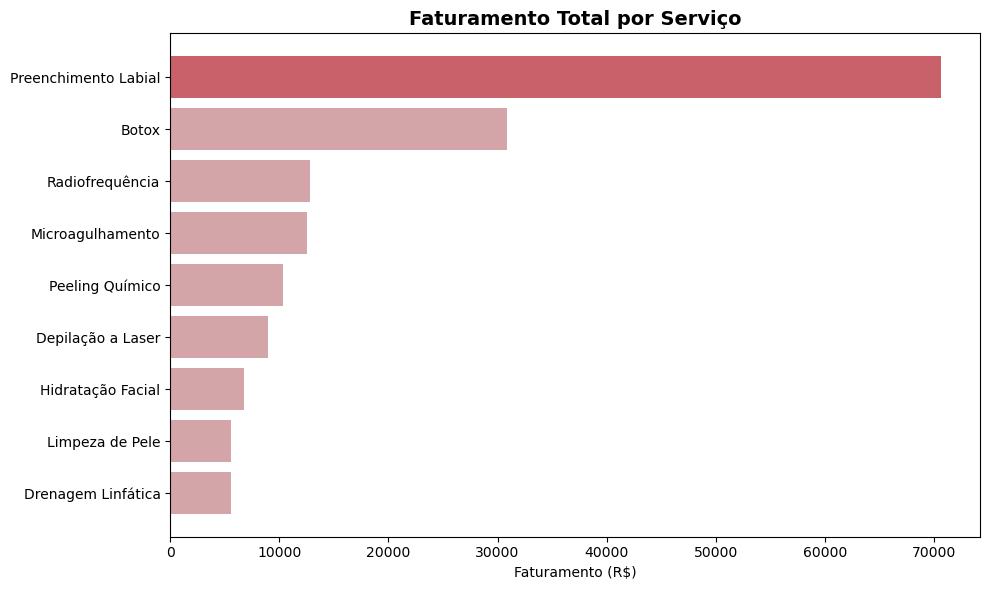

servico
Drenagem Linfática       5541.15
Limpeza de Pele          5561.83
Hidratação Facial        6760.31
Depilação a Laser        8961.44
Peeling Químico         10328.62
Microagulhamento        12543.39
Radiofrequência         12783.11
Botox                   30882.48
Preenchimento Labial    70690.74


In [5]:
import matplotlib.pyplot as plt

# Apenas atendimentos realizados
df_realizado = df[df["status"] == "Realizado"]

fat_servico = (df_realizado
    .groupby("servico")["valor_R$"]
    .sum()
    .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#C9616A' if v == fat_servico.max() else '#D4A5A8'
         for v in fat_servico.values]
ax.barh(fat_servico.index, fat_servico.values, color=cores)
ax.set_title('Faturamento Total por Serviço', fontsize=14, fontweight='bold')
ax.set_xlabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('grafico_faturamento.png', dpi=150)
plt.show()
print(fat_servico.to_string())

In [6]:
# Taxa de cancelamento geral
total = len(df)
cancelados = len(df[df["status"].isin(["Cancelado", "Faltou"])])
taxa = (cancelados / total) * 100
print(f"Taxa de não comparecimento: {taxa:.1f}%")

# Cancelamentos por profissional
cancel_prof = (df[df["status"] != "Realizado"]
    .groupby("profissional")
    .size()
    .sort_values(ascending=False))
print("\nCancelamentos por profissional:")
print(cancel_prof)

# Dia da semana com mais faltas
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
faltas_dia = (df[df["status"] == "Faltou"]
    .groupby("dia_semana")
    .size()
    .reindex(ordem_dias, fill_value=0))
print("\nFaltas por dia da semana:")
print(faltas_dia)

Taxa de não comparecimento: 37.6%

Cancelamentos por profissional:
profissional
Esteta Renata        53
Dra. Paula Mendes    46
Esteta Carla         46
Dra. Ana Lima        43
dtype: int64

Faltas por dia da semana:
dia_semana
Monday       10
Tuesday      17
Wednesday     9
Thursday     19
Friday       13
Saturday     12
dtype: int64


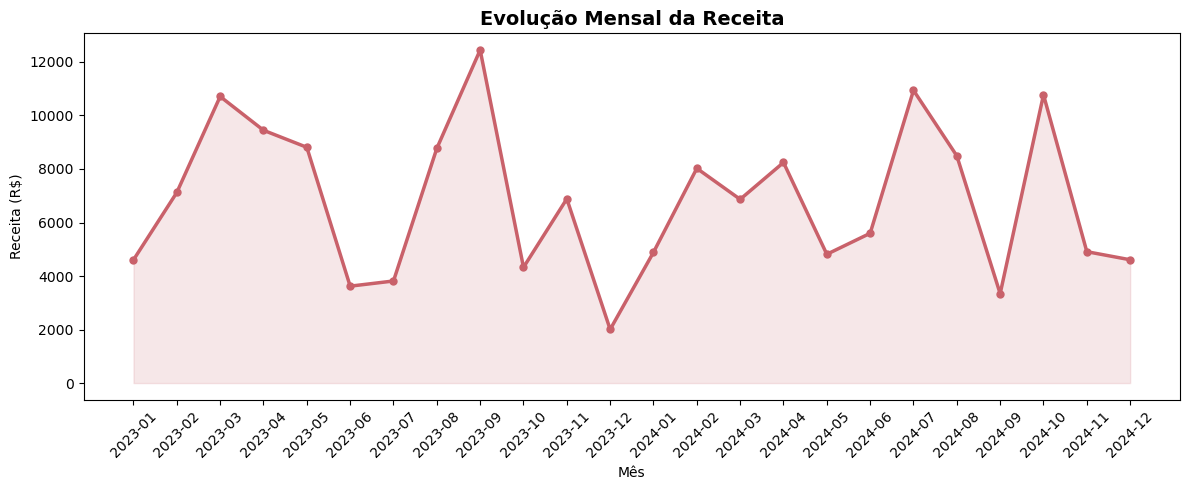

In [7]:
# Receita mensal
receita_mensal = (df_realizado
    .groupby("mes")["valor_R$"]
    .sum()
    .reset_index()
    .sort_values("mes"))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(receita_mensal["mes"], receita_mensal["valor_R$"],
        color='#C9616A', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(receita_mensal["mes"], receita_mensal["valor_R$"],
                alpha=0.15, color='#C9616A')
ax.set_title('Evolução Mensal da Receita', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Receita (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_receita_mensal.png', dpi=150)
plt.show()

In [8]:
import sqlite3

# Criar banco e carregar os dados
conn = sqlite3.connect("clinica.db")
df.to_sql("atendimentos", conn, if_exists="replace", index=False)

# Testar conexão
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM atendimentos")
print(f"Registros no banco: {cursor.fetchone()[0]}")
conn.close()

Registros no banco: 500


In [10]:
conn = sqlite3.connect("clinica.db")

q1 = """
SELECT 
    servico,
    COUNT(*) AS total_atendimentos,
    ROUND(SUM(valor_R$), 2) AS faturamento_total,
    ROUND(AVG(valor_R$), 2) AS ticket_medio
FROM atendimentos
WHERE status = 'Realizado'
GROUP BY servico
ORDER BY faturamento_total DESC
"""

q2 = """
SELECT
    profissional,
    COUNT(*) AS total_agendamentos,
    SUM(CASE WHEN status = 'Realizado' THEN 1 ELSE 0 END) AS realizados,
    ROUND(
        100.0 * SUM(CASE WHEN status != 'Realizado' THEN 1 ELSE 0 END) / COUNT(*), 1
    ) AS taxa_cancelamento_pct
FROM atendimentos
GROUP BY profissional
ORDER BY taxa_cancelamento_pct DESC
"""

q3 = """
SELECT mes, ROUND(SUM(valor_R$), 2) AS receita
FROM atendimentos
WHERE status = 'Realizado'
GROUP BY mes
ORDER BY mes
"""

for nome, query in [("Top Serviços", q1), ("Cancelamentos", q2), ("Receita Mensal", q3)]:
    print(f"\n=== {nome} ===")
    print(pd.read_sql(query, conn).to_string(index=False))

conn.close()


=== Top Serviços ===
             servico  total_atendimentos  faturamento_total  ticket_medio
Preenchimento Labial                  47           70690.74       1504.06
               Botox                  26           30882.48       1187.79
     Radiofrequência                  36           12783.11        355.09
    Microagulhamento                  31           12543.39        404.63
     Peeling Químico                  34           10328.62        303.78
   Depilação a Laser                  36            8961.44        248.93
   Hidratação Facial                  34            6760.31        198.83
     Limpeza de Pele                  31            5561.83        179.41
  Drenagem Linfática                  37            5541.15        149.76

=== Cancelamentos ===
     profissional  total_agendamentos  realizados  taxa_cancelamento_pct
    Esteta Renata                 121          68                   43.8
    Dra. Ana Lima                 115          72                   3